<a href="https://colab.research.google.com/github/LimaHossain/Customer-Churn-Prediction/blob/main/Customer_Churn_Prediction_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve, auc,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [37]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [42]:
import zipfile
zipfile.ZipFile("archive.zip").extractall()

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [43]:
print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 rows: ")
print(df.head())

Dataset Shape: (7043, 21)

First 5 rows: 
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Stream

In [44]:
print("\nData Info: ")
print(df.info())


Data Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-nu

In [45]:
print("\nMissing Values: ")
print(df.isnull().sum())


Missing Values: 
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [46]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Missing in TotalCharges after conversion: {df['TotalCharges'].isnull().sum()}")

Missing in TotalCharges after conversion: 11


In [47]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df.drop('customerID', axis=1, inplace=True)

In [48]:
print("\nChurn Distribution:")
print(df['Churn'].value_counts(normalize=True))


Churn Distribution:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


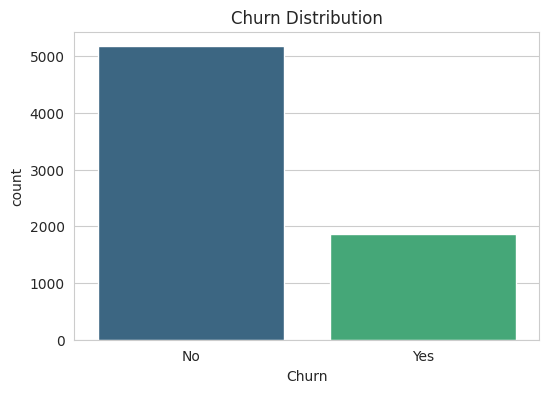

In [49]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Churn Distribution')
plt.show()

In [50]:
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])

cat_cols = df.select_dtypes(include=['object']).columns
print(f"\nCategorical Columns: {list(cat_cols)}")


Categorical Columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [51]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(f"Shape after encoding: {df_encoded.shape}")

Shape after encoding: (7043, 31)


In [52]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [53]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [54]:
X_train_tree = X_train.copy()
X_test_tree = X_test.copy()

In [55]:
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Training samples: 5634, Test samples: 1409


In [56]:
models = {}
predictions = {}
probabilities = {}

print("\n" + "="*60)
print("A. LOGISTIC REGRESSION")
print("="*60)

print("Concept: Logistic Regression uses the sigmoid function σ(z) = 1/(1+e^(-z)) to map linear input to probability [0,1].")
print("It models P(y=1|X) and classifies using threshold (usually 0.5).")


A. LOGISTIC REGRESSION
Concept: Logistic Regression uses the sigmoid function σ(z) = 1/(1+e^(-z)) to map linear input to probability [0,1].
It models P(y=1|X) and classifies using threshold (usually 0.5).


In [57]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
y_pred_lr = logreg.predict(X_test_scaled)
y_prob_lr = logreg.predict_proba(X_test_scaled)[:, 1]

models['Logistic Regression'] = logreg
predictions['Logistic Regression'] = y_pred_lr
probabilities['Logistic Regression'] = y_prob_lr

In [58]:
print("\n" + "="*60)
print("B. K-NEAREST NEIGHBORS (KNN)")
print("="*60)

print("Concept: KNN predicts based on majority class of K closest points using distance (e.g., Euclidean).")
print("Requires scaling. Performance depends on K.")


B. K-NEAREST NEIGHBORS (KNN)
Concept: KNN predicts based on majority class of K closest points using distance (e.g., Euclidean).
Requires scaling. Performance depends on K.


In [59]:
k_values = [3, 5, 7, 9]
knn_scores = []

In [60]:
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    f1 = f1_score(y_test, y_pred)
    knn_scores.append(f1)
    print(f"K={k}, F1 Score: {f1:.4f}")

best_k = k_values[np.argmax(knn_scores)]
print(f"\nBest K: {best_k}")

K=3, F1 Score: 0.5128
K=5, F1 Score: 0.5123
K=7, F1 Score: 0.5344
K=9, F1 Score: 0.5586

Best K: 9


In [61]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

models['KNN'] = knn
predictions['KNN'] = y_pred_knn
probabilities['KNN'] = y_prob_knn

In [62]:
print("\n" + "="*60)
print("C. DECISION TREE")
print("="*60)

print("Concept: Splits data recursively based on feature thresholds to maximize information gain (Gini/Entropy).")
print("Prone to overfitting → use max_depth, min_samples_leaf.")


C. DECISION TREE
Concept: Splits data recursively based on feature thresholds to maximize information gain (Gini/Entropy).
Prone to overfitting → use max_depth, min_samples_leaf.


In [63]:
param_grid_dt = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [1, 5, 10]
}

dt = DecisionTreeClassifier(random_state=42)
grid_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='f1')
grid_dt.fit(X_train_tree, y_train)

print(f"Best params: {grid_dt.best_params_}")

Best params: {'max_depth': 7, 'min_samples_leaf': 1}


In [64]:
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test_tree)
y_prob_dt = best_dt.predict_proba(X_test_tree)[:, 1]

models['Decision Tree'] = best_dt
predictions['Decision Tree'] = y_pred_dt
probabilities['Decision Tree'] = y_prob_dt

print("\n" + "="*60)
print("D. RANDOM Forest")
print("="*60)

print("Concept: Ensemble of decision trees using bagging + random feature subsets.")
print("Reduces overfitting, robust, provides feature importance.")


D. RANDOM Forest
Concept: Ensemble of decision trees using bagging + random feature subsets.
Reduces overfitting, robust, provides feature importance.


In [66]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring = 'f1')
grid_rf.fit(X_train_tree, y_train)

print(f"Best params: {grid_rf.best_params_}")

Best params: {'max_depth': 10, 'max_features': 'log2', 'n_estimators': 200}


In [67]:
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_tree)
y_prob_rf = best_rf.predict_proba(X_test_tree)[:, 1]

models['Random Forest'] = best_rf
predictions['Random Forest'] = y_pred_rf
probabilities['Random Forest'] = y_prob_rf


MODEL EVALUATION & COMPARISON


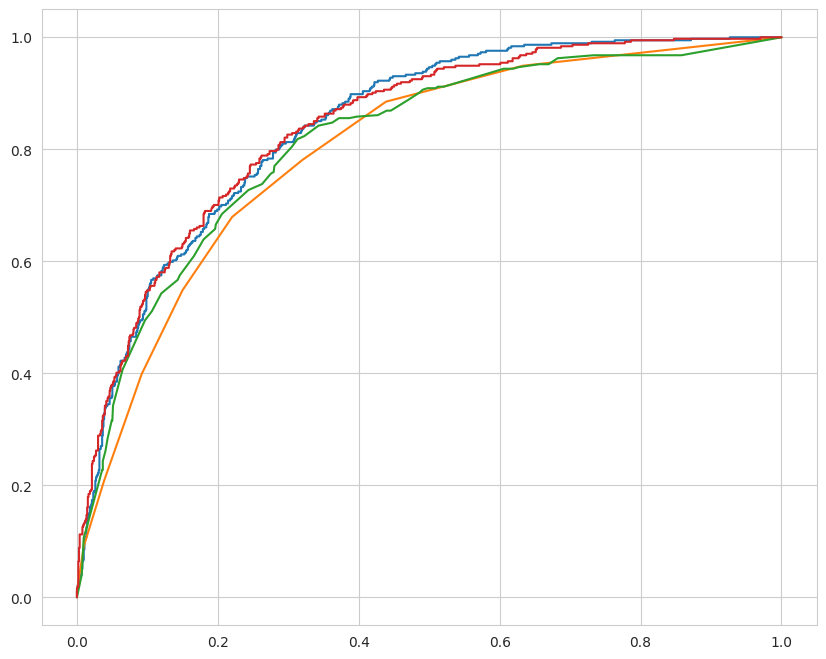

In [68]:
results = []

print("\n" + "="*80)
print("MODEL EVALUATION & COMPARISON")
print("="*80)

plt.figure(figsize=(10, 8))

for name in models.keys():
    y_prob = probabilities[name]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

    # Metrics
    y_pred = predictions[name]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc,
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn
    })

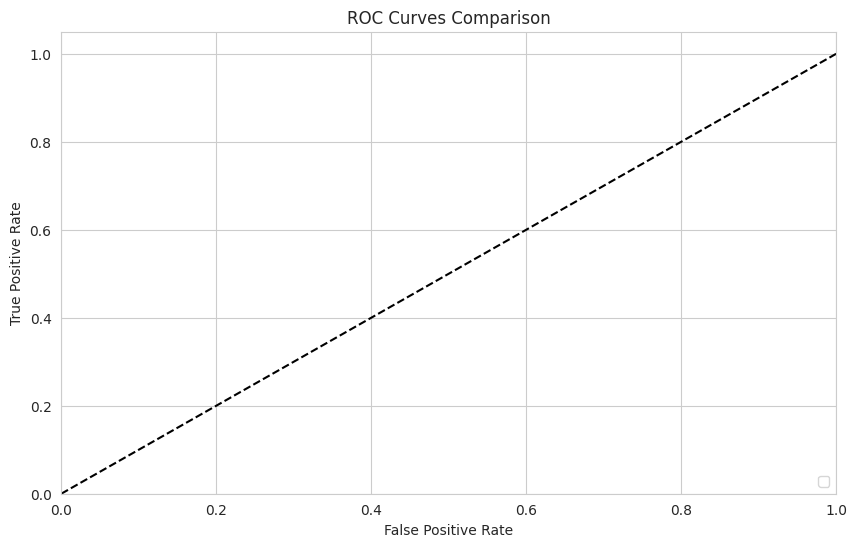

In [69]:
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc="lower right")
plt.show()

In [70]:
results_df = pd.DataFrame(results)
results_df = results_df.round(4)
results_df = results_df.sort_values(by='F1 Score', ascending=False)

print("\nPERFORMANCE SUMMARY TABLE")
print("="*100)
print(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']])
print("="*100)


PERFORMANCE SUMMARY TABLE
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.8070     0.6584  0.5668    0.6092   0.8416
3        Random Forest    0.8055     0.6761  0.5134    0.5836   0.8413
2        Decision Tree    0.7906     0.6208  0.5428    0.5792   0.8137
1                  KNN    0.7700     0.5694  0.5481    0.5586   0.7992



FEATURE IMPORTANCE COMPARISON


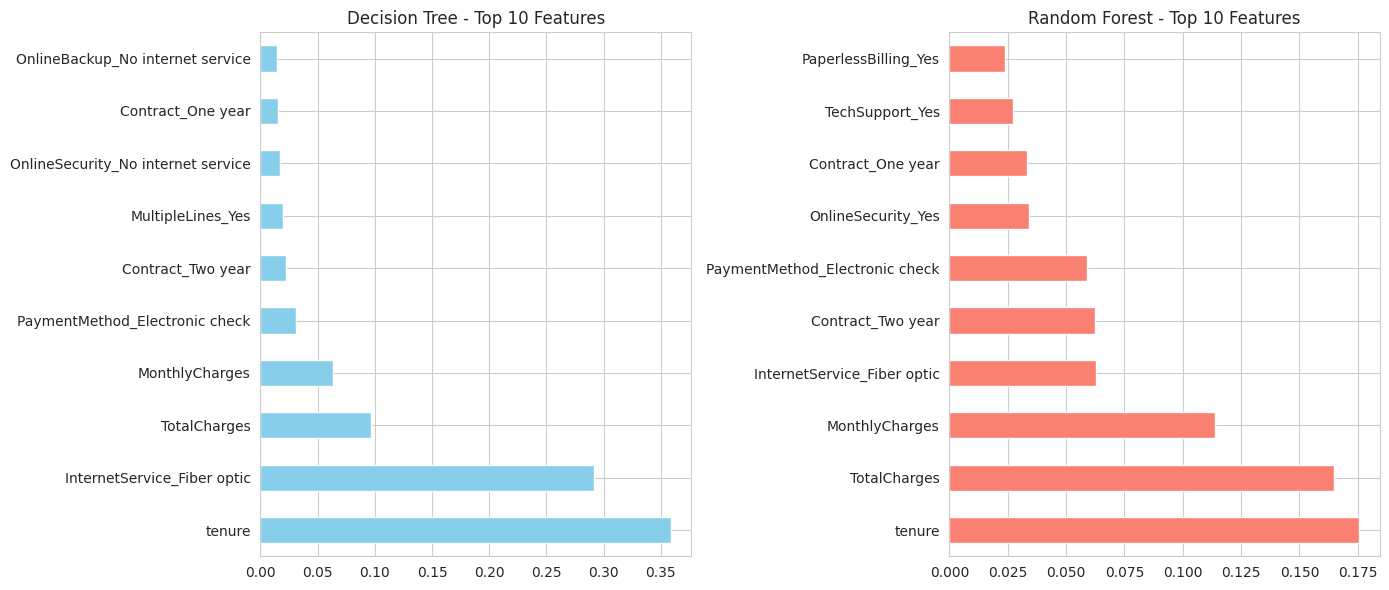

In [71]:
print("\nFEATURE IMPORTANCE COMPARISON")

feat_importance_dt = pd.Series(best_dt.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
feat_importance_rf = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
feat_importance_dt.plot(kind='barh', ax=ax1, title='Decision Tree - Top 10 Features', color='skyblue')
feat_importance_rf.plot(kind='barh', ax=ax2, title='Random Forest - Top 10 Features', color='salmon')
plt.tight_layout()
plt.show()

In [72]:
results_df.to_csv('churn_model_comparison.csv', index=False)
print("Results saved to 'churn_model_comparison.csv'")

Results saved to 'churn_model_comparison.csv'
